<a href="https://colab.research.google.com/github/aditya-srivastava010/KAMADO-999-AI-ML-TRAINNING/blob/main/MULTI_VARIABLE_PREDICTION_DAY_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== DATASET LOADED ===
Shape: (500, 10)

First 5 rows:
   area_sqft  bedrooms  bathrooms  age_years  floors  garage_spaces  \
0       1360         1          3         27       2              0   
1       4272         1          2         14       2              1   
2       3592         3          2         29       1              2   
3        966         5          2         36       3              0   
4       4926         4          1         28       1              0   

   distance_to_city_km  crime_rate  school_rating  price_usd  
0                  2.6        0.25              4     213500  
1                 15.9        3.85              8     526400  
2                 33.0        3.44             10     409500  
3                 47.0        0.29              7      64900  
4                 43.7        1.33              9     562000  

Data types:
area_sqft                int64
bedrooms                 int64
bathrooms                int64
age_years                int64
flo

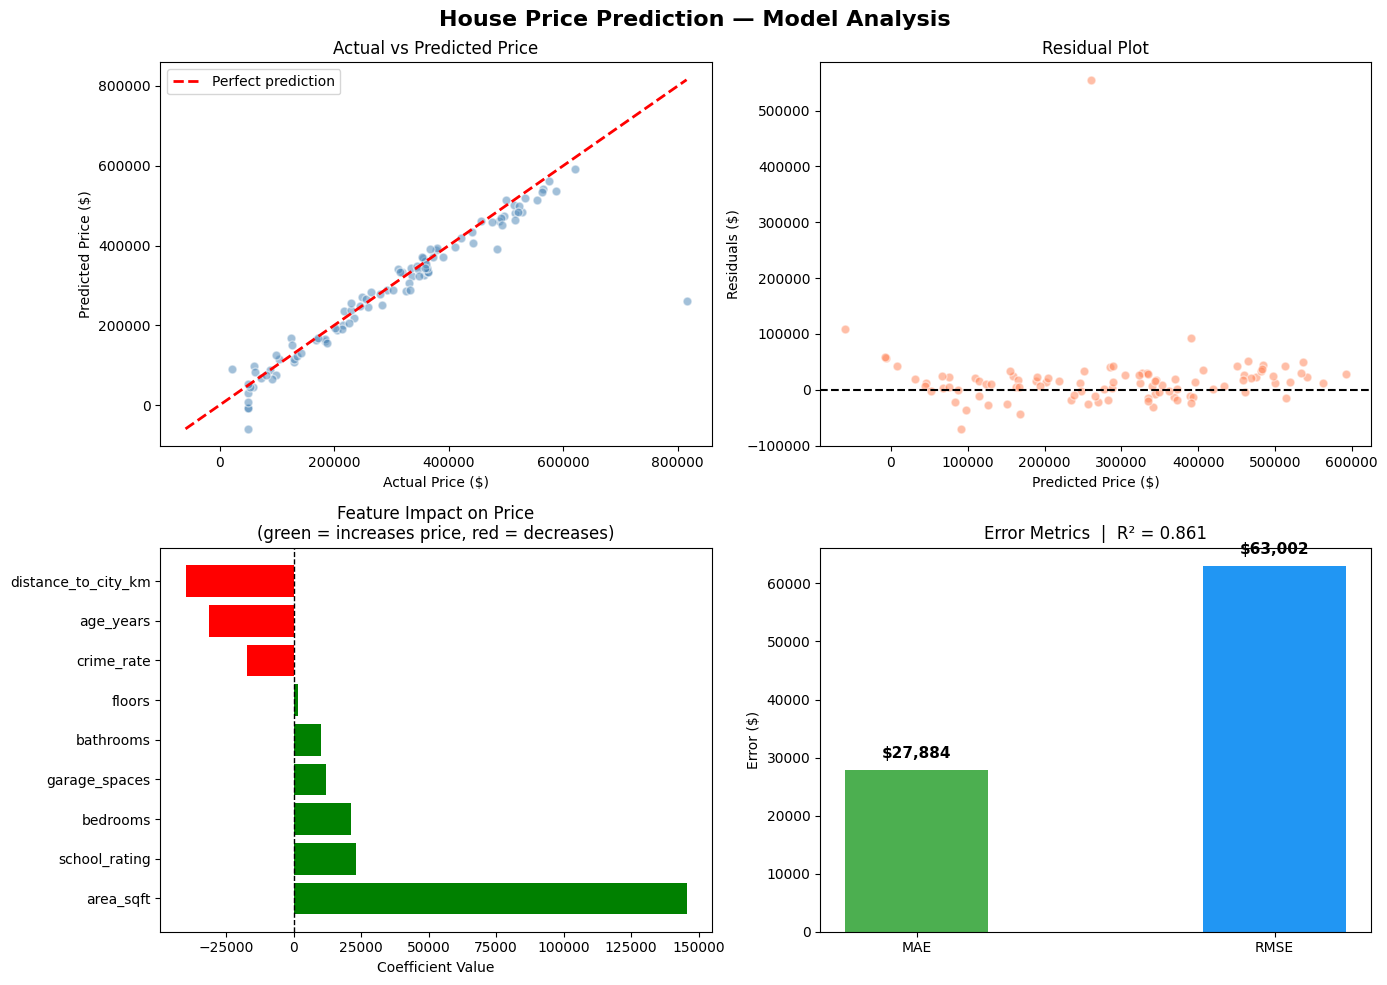


=== PLOTS DISPLAYED ===

=== PREDICT A NEW HOUSE ===
Input house: 2500sqft, 3bed, 2bath, 10yrs old, 2floors
             Garage:1, 15km from city, crime:3.0, school:7

Predicted Price: $361,726


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# STEP 1: Load Dataset
# ============================================================
df = pd.read_csv("house_price_data.csv")
print("=== DATASET LOADED ===")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

# ============================================================
# STEP 2: EDA — Basic Stats + Outlier Detection
# ============================================================
print("\n=== BASIC STATISTICS ===")
print(df.describe())

# Outlier detection using IQR for price
Q1 = df['price_usd'].quantile(0.25)
Q3 = df['price_usd'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['price_usd'] < lower) | (df['price_usd'] > upper)]
print(f"\n=== OUTLIER DETECTION (IQR method) ===")
print(f"Lower bound: ${lower:,.0f}")
print(f"Upper bound: ${upper:,.0f}")
print(f"Outliers found: {len(outliers)} rows")
print(outliers[['area_sqft', 'price_usd']].head(10))

# ============================================================
# STEP 3: Data Cleaning — Remove Outliers
# ============================================================
df_clean = df[(df['price_usd'] >= lower) & (df['price_usd'] <= upper)]
print(f"\n=== AFTER CLEANING ===")
print(f"Original rows: {len(df)}")
print(f"Cleaned rows:  {len(df_clean)}")
print(f"Removed:       {len(df) - len(df_clean)} outlier rows")

# Also fix abnormal area_sqft (some values like 28386 are outliers)
area_Q3 = df_clean['area_sqft'].quantile(0.99)
df_clean = df_clean[df_clean['area_sqft'] <= area_Q3]
print(f"After area outlier removal: {len(df_clean)} rows")

# ============================================================
# STEP 4: Feature Selection & Splitting
# ============================================================
features = ['area_sqft', 'bedrooms', 'bathrooms', 'age_years',
            'floors', 'garage_spaces', 'distance_to_city_km',
            'crime_rate', 'school_rating']

X = df_clean[features]
y = df_clean['price_usd']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n=== TRAIN/TEST SPLIT ===")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

# ============================================================
# STEP 5: Feature Scaling
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("\n=== SCALING DONE (StandardScaler) ===")

# ============================================================
# STEP 6: Train Linear Regression Model
# ============================================================
model = LinearRegression()
model.fit(X_train_scaled, y_train)
print("\n=== MODEL TRAINED ===")

# Feature importance (coefficients)
coeff_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)
print("\nFeature Coefficients (impact on price):")
print(coeff_df.to_string(index=False))

# ============================================================
# STEP 7: Predictions
# ============================================================
y_pred = model.predict(X_test_scaled)

# ============================================================
# STEP 8: Evaluation — MSE, RMSE, MAE, R2
# ============================================================
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("\n=== MODEL EVALUATION ===")
print(f"MSE  (Mean Squared Error)  : {mse:,.2f}")
print(f"RMSE (Root MSE)            : ${rmse:,.2f}")
print(f"MAE  (Mean Absolute Error) : ${mae:,.2f}")
print(f"R²   (R-squared Score)     : {r2:.4f}  ({r2*100:.1f}% variance explained)")

# Comparison table
print("\n--- What these mean ---")
print(f"  On average, model is off by ±${mae:,.0f} (MAE)")
print(f"  RMSE penalizes big errors more: ±${rmse:,.0f}")
print(f"  R² = {r2:.2f} → model explains {r2*100:.1f}% of price variation")

# ============================================================
# STEP 9: Visualizations
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("House Price Prediction — Model Analysis", fontsize=16, fontweight='bold')

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='white', s=40)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
axes[0, 0].set_xlabel("Actual Price ($)")
axes[0, 0].set_ylabel("Predicted Price ($)")
axes[0, 0].set_title("Actual vs Predicted Price")
axes[0, 0].legend()

# Plot 2: Residuals
residuals = y_test - y_pred
axes[0, 1].scatter(y_pred, residuals, alpha=0.5, color='coral', edgecolors='white', s=40)
axes[0, 1].axhline(y=0, color='black', linestyle='--', lw=1.5)
axes[0, 1].set_xlabel("Predicted Price ($)")
axes[0, 1].set_ylabel("Residuals ($)")
axes[0, 1].set_title("Residual Plot")

# Plot 3: Feature Coefficients
colors = ['green' if c > 0 else 'red' for c in coeff_df['Coefficient']]
axes[1, 0].barh(coeff_df['Feature'], coeff_df['Coefficient'], color=colors)
axes[1, 0].axvline(x=0, color='black', linestyle='--', lw=1)
axes[1, 0].set_xlabel("Coefficient Value")
axes[1, 0].set_title("Feature Impact on Price\n(green = increases price, red = decreases)")

# Plot 4: Metrics Bar Chart
metrics = {'MAE': mae, 'RMSE': rmse}
bars = axes[1, 1].bar(metrics.keys(), metrics.values(), color=['#4CAF50', '#2196F3'], width=0.4)
axes[1, 1].set_ylabel("Error ($)")
axes[1, 1].set_title(f"Error Metrics  |  R² = {r2:.3f}")
for bar, val in zip(bars, metrics.values()):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                    f'${val:,.0f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()
print("\n=== PLOTS DISPLAYED ===")

# ============================================================
# STEP 10: Predict a New House
# ============================================================
print("\n=== PREDICT A NEW HOUSE ===")
new_house = pd.DataFrame([{
    'area_sqft': 2500,
    'bedrooms': 3,
    'bathrooms': 2,
    'age_years': 10,
    'floors': 2,
    'garage_spaces': 1,
    'distance_to_city_km': 15,
    'crime_rate': 3.0,
    'school_rating': 7
}])
new_scaled = scaler.transform(new_house)
predicted_price = model.predict(new_scaled)[0]
print(f"Input house: 2500sqft, 3bed, 2bath, 10yrs old, 2floors")
print(f"             Garage:1, 15km from city, crime:3.0, school:7")
print(f"\nPredicted Price: ${predicted_price:,.0f}")